In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

# File path
DATA_PATH = 'fakejob_vs_realjob.csv'



In [2]:
# 1. Load Data
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (20000, 11)


,job_title,company,location,job_type,experience,skills,salary,last_date,is_remote,posted_days_ago,is_fake
0,Data Scientist,ZenithTech Staffing,"Jaipur, Rajasthan",Part-time,0-2 years,"""TensorFlow, English, Scikit-learn, Teamwork, ...",₹39.8-49.8 LPA,2025-12-10,No,202,1
1,Data Scientist,ApexByte,Hybrid - Bangalore,Contract (6 months),0-2 years,"""Seaborn, Agile, Spark, SQL, TensorFlow, PyTor...",₹4.3-9.9 LPA,2025-07-31,Yes,154,0
2,Python Developer,AnalyticsHub,Hybrid - Mumbai,Contract (6 months),3-6 years,"""Git, REST API, PostgreSQL, Celery, Agile, Mon...",₹3.0-16.1 LPA,2025-12-24,No,66,0
3,Next.js Developer,SkyNet International Careers,"Chennai, Tamil Nadu",Part-time,1-3 years,"""Agile, HTML5, TypeScript, Redux, Git, Tailwin...",₹23.7-33.1 LPA,2025-09-29,No,64,1
4,MERN Stack Developer,TCS Digital,"Chennai, Tamil Nadu",Contract (6 months),2-5 years,"""Git, Jira, Teamwork, Communication, English, ...",₹5.5-11.1 LPA,2025-11-07,Yes,169,0


In [3]:
# 2. Preprocessing
# Handle missing values
df = df.fillna('missing')

# Combine text fields for NLP
text_features = ['job_title', 'company', 'location', 'skills']
df['combined_text'] = df[text_features].apply(lambda x: ' '.join(x.values.astype(str)), axis=1)

# Define feature groups
target = 'is_fake'
cat_cols = ['job_type', 'experience', 'is_remote']
# num_cols = ['posted_days_ago'] # Removed as requested
text_col = 'combined_text'

X = df[[text_col] + cat_cols]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Preprocessing complete. Columns used for training:")
print(X.columns.tolist())

Preprocessing complete. Columns used for training:
['combined_text', 'job_type', 'experience', 'is_remote']


In [4]:
# 3. Build Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, stop_words='english'), text_col),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("Training Pipeline created.")

Training Pipeline created.


In [5]:
# 4. Train Model
print("Training in progress...")
model.fit(X_train, y_train)
print("Training complete.")

Training in progress...
Training complete.



Model Accuracy: 0.9752

Classification Report slice (first few results):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3286
           1       1.00      0.86      0.93       714

    accuracy                           0.98      4000
   macro avg       0.98      0.93      0.96      4000
weighted avg       0.98      0.98      0.97      4000



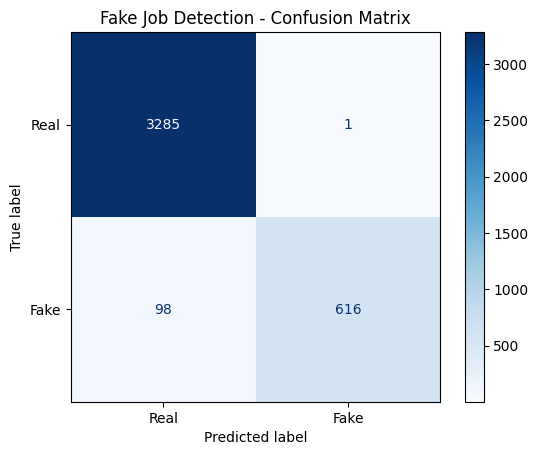

In [6]:
# 5. Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report slice (first few results):")
print(classification_report(y_test, y_pred))

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Fake Job Detection - Confusion Matrix')
plt.show()

In [7]:
# 6. Save Model
import joblib

MODEL_FILENAME = 'fake_job_model.joblib'
joblib.dump(model, MODEL_FILENAME)
print(f"Model saved successfully to {MODEL_FILENAME}")

Model saved successfully to fake_job_model.joblib
